<a href="https://colab.research.google.com/github/itsebuka/Enhanced-Volatge-stability-Model/blob/main/Voltage_Stability_Prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DOWNLOADING DATASET
✓ Dataset downloaded successfully

Validating dataset...
✓ Dataset validation passed

DATA PREPROCESSING & CLASS BALANCE CHECK

✓ Class Distribution BEFORE splitting:
  Unstable   (Class 0):   6380 samples (63.80%)
  Stable     (Class 1):   3620 samples (36.20%)
Training set size: 8000 samples
Testing set size:  2000 samples

FEATURE CORRELATION WITH STABILITY

Correlation with Stability (1=Stable, 0=Unstable):
p4      0.022785
p3      0.000649
p2     -0.006173
p1     -0.009938
g1     -0.197664
g4     -0.204931
g2     -0.217341
g3     -0.231774
tau1   -0.234898
tau3   -0.237492
tau4   -0.239375
tau2   -0.246280
dtype: float64


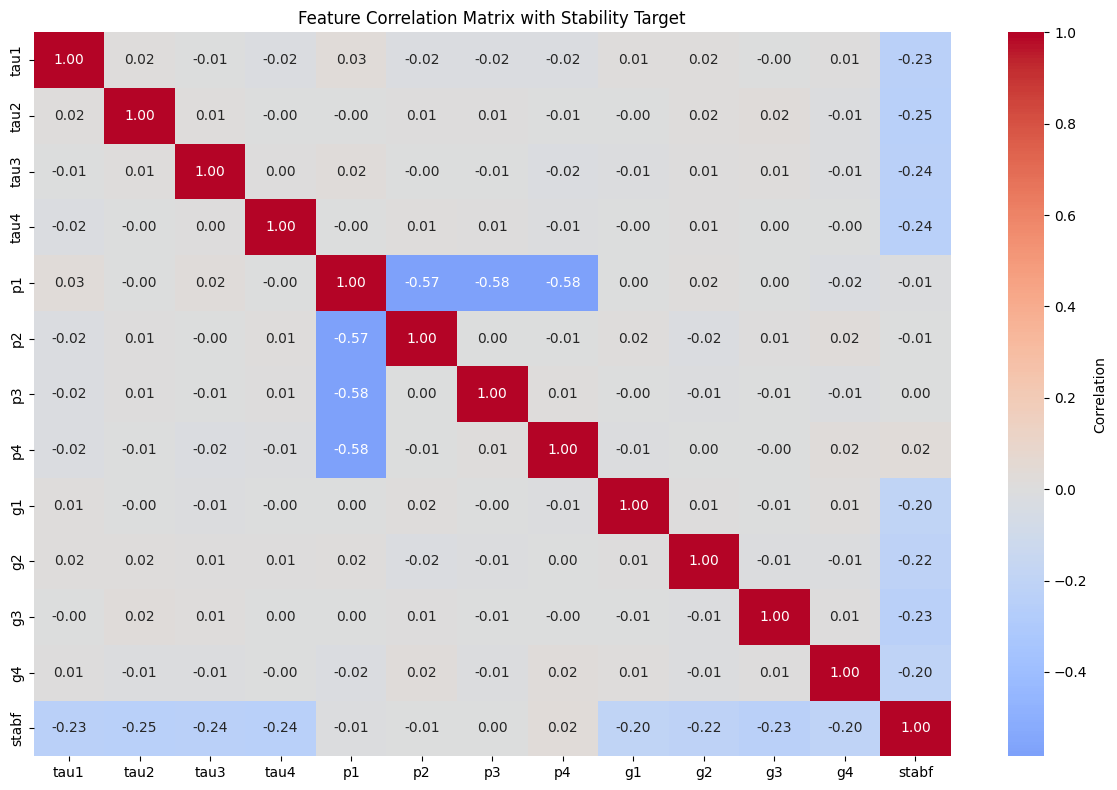

In [19]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

# Ensure output directories exist
os.makedirs(CONFIG['model_dir'], exist_ok=True)
os.makedirs(CONFIG['output_dir'], exist_ok=True)

print("=" * 60)
print("DOWNLOADING DATASET")
print("=" * 60)
try:
    df = pd.read_csv(CONFIG['https://archive.ics.uci.edu/ml/machine-learning-databases/00471/Data_for_UCI_named.csv'])
    print(f"✓ Dataset downloaded successfully")
except Exception as e:
    print(f"✗ ERROR downloading dataset: {e}")
    raise

print("\nValidating dataset...")
if df.shape[0] == 0:
    raise ValueError("Downloaded dataset is empty!")
if 'stabf' not in df.columns:
    raise ValueError("Required column 'stabf' not found in dataset!")
print(f"✓ Dataset validation passed")

print("\n" + "=" * 60)
print("DATA PREPROCESSING & CLASS BALANCE CHECK")
print("=" * 60)

# Drop continuous 'stab', focus on 'stabf'
df = df.drop(columns=['stab'])
df['stabf'] = df['stabf'].map({'stable': 1, 'unstable': 0})

print("\n✓ Class Distribution BEFORE splitting:")
class_counts = df['stabf'].value_counts()
class_pct = df['stabf'].value_counts(normalize=True) * 100
for label, count in class_counts.items():
    pct = class_pct[label]
    status = "Stable" if label == 1 else "Unstable"
    print(f"  {status:10} (Class {label}): {count:6} samples ({pct:5.2f}%)")

X = df.drop(columns=['stabf'])
y = df['stabf']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=CONFIG['random_state'], stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH STABILITY")
print("=" * 60)
correlation_with_stability = X.corrwith(y).sort_values(ascending=False)
print("\nCorrelation with Stability (1=Stable, 0=Unstable):")
print(correlation_with_stability)

plt.figure(figsize=(12, 8))
correlation_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix with Stability Target')
plt.tight_layout()
plt.show()

In [20]:
print("\n" + "=" * 60)
print("DATA SCALING (for distance-based algorithms)")
print("=" * 60)
print("StandardScaler centers features to mean=0, std=1")
print("This is REQUIRED for Logistic Regression but NOT for Decision Trees\n")

scaler = StandardScaler()
X_train_scaled_arr = scaler.fit_transform(X_train)
X_test_scaled_arr = scaler.transform(X_test)

# ========== ISSUE #3: Preserve feature names after scaling ==========
X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=X_test.columns, index=X_test.index)

print("✓ Scaling complete with feature names preserved")
print(f"  Scaled training data shape: {X_train_scaled.shape}")
print(f"  Scaled testing data shape:  {X_test_scaled.shape}")
print(f"  Features: {list(X_train_scaled.columns)}")
print(f"  Sample scaled values (first row): {X_train_scaled.iloc[0, :3].values}")


DATA SCALING (for distance-based algorithms)
StandardScaler centers features to mean=0, std=1
This is REQUIRED for Logistic Regression but NOT for Decision Trees

✓ Scaling complete with feature names preserved
  Scaled training data shape: (8000, 12)
  Scaled testing data shape:  (2000, 12)
  Features: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
  Sample scaled values (first row): [-0.424656    1.25667699  0.14023222]



LOGISTIC REGRESSION - TRAINING & EVALUATION
✓ Model trained successfully

--- CROSS-VALIDATION (5-Fold Stratified) ---
Cross-Val Accuracy: 0.8154 ± 0.0077
Cross-Val F1-Score: 0.7344 ± 0.0111
Individual fold accuracies: ['0.8100', '0.8087', '0.8269', '0.8087', '0.8225']

TEST SET PERFORMANCE
Accuracy:            81.85%
Balanced Accuracy:   79.29%  (better for imbalanced)
F1-Score:           0.7364  (harmonic mean of precision & recall)

Detailed Classification Report:
              precision    recall  f1-score   support

Unstable (0)       0.84      0.89      0.86      1276
  Stable (1)       0.78      0.70      0.74       724

    accuracy                           0.82      2000
   macro avg       0.81      0.79      0.80      2000
weighted avg       0.82      0.82      0.82      2000


Confusion Matrix:
                 Predicted
                 Unstable  Stable
Actual Unstable     1130     146
Actual Stable        217     507


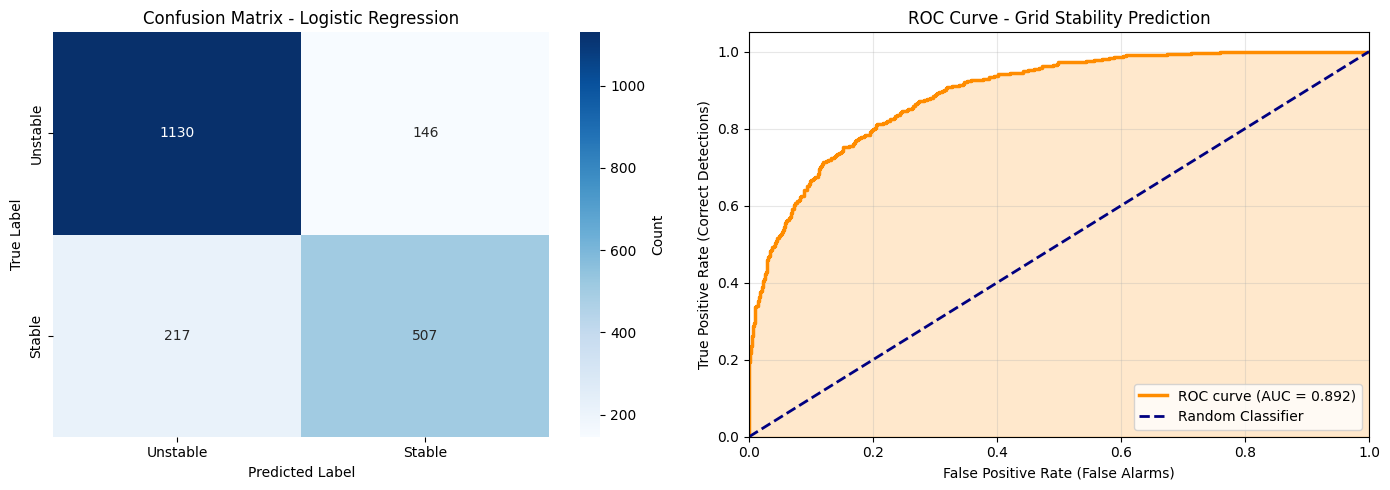

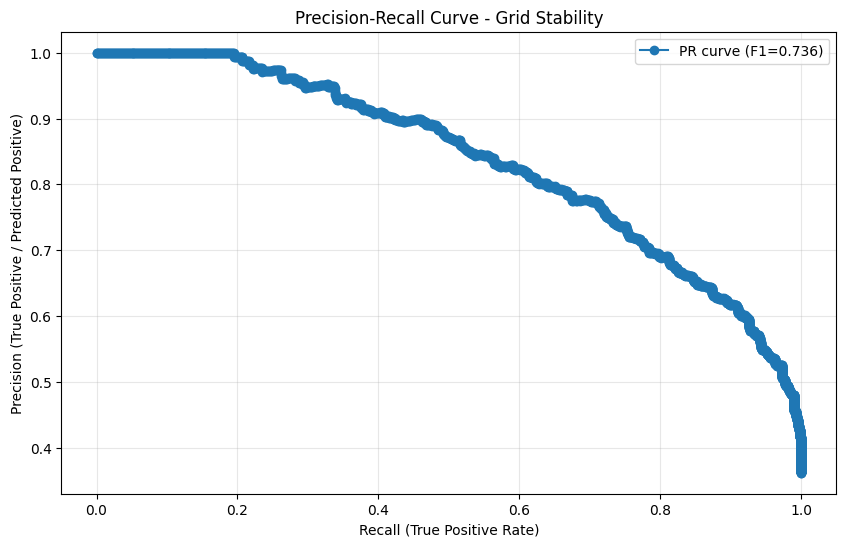

In [21]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION - TRAINING & EVALUATION")
print("=" * 60)

# 1. Initialize and Train the Model
model = LogisticRegression(random_state=CONFIG['random_state'], max_iter=1000)
model.fit(X_train_scaled, y_train)

print("✓ Model trained successfully")

# 2. CROSS-VALIDATION: Test generalization (K-Fold)
print(f"\n--- CROSS-VALIDATION ({CONFIG['cv_splits']}-Fold Stratified) ---")
cv_strategy = StratifiedKFold(n_splits=CONFIG['cv_splits'], shuffle=True, random_state=CONFIG['random_state'])
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy,
                             scoring='accuracy')
cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy,
                        scoring='f1')
print(f"Cross-Val Accuracy: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")
print(f"Cross-Val F1-Score: {cv_f1.mean():.4f} \u00b1 {cv_f1.std():.4f}")
print(f"Individual fold accuracies: {[f'{s:.4f}' for s in cv_scores]}")

# 3. Make Predictions on the unseen 20% of data
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of being stable

# 4. Calculate Multiple Metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)  # Better for imbalanced data
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:           {accuracy * 100:6.2f}%")
print(f"Balanced Accuracy:  {balanced_acc * 100:6.2f}%  (better for imbalanced)")
print(f"F1-Score:           {f1:.4f}  (harmonic mean of precision & recall)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Unstable (0)', 'Stable (1)']))

# 5. CONFUSION MATRIX - Visual breakdown
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Unstable  Stable")
print(f"Actual Unstable    {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"Actual Stable      {cm[1,0]:5d}   {cm[1,1]:5d}")

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unstable', 'Stable'],
            yticklabels=['Unstable', 'Stable'],
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (False Alarms)')
axes[1].set_ylabel('True Positive Rate (Correct Detections)')
axes[1].set_title('ROC Curve - Grid Stability Prediction')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. PRECISION-RECALL CURVE (Alternative to ROC)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='o', label=f'PR curve (F1={f1:.3f})')
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (True Positive / Predicted Positive)')
plt.title('Precision-Recall Curve - Grid Stability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


FEATURE IMPORTANCE & GRID VULNERABILITY ANALYSIS

Feature Importance Ranking:
(Positive = Stabilizing | Negative = Destabilizing)

tau4       | Coef:  -0.9074 | DESTABILIZING | Impact: 0.9074
tau1       | Coef:  -0.8910 | DESTABILIZING | Impact: 0.8910
tau2       | Coef:  -0.8867 | DESTABILIZING | Impact: 0.8867
tau3       | Coef:  -0.8657 | DESTABILIZING | Impact: 0.8657
g3         | Coef:  -0.8605 | DESTABILIZING | Impact: 0.8605
g2         | Coef:  -0.8129 | DESTABILIZING | Impact: 0.8129
g4         | Coef:  -0.7489 | DESTABILIZING | Impact: 0.7489
g1         | Coef:  -0.7301 | DESTABILIZING | Impact: 0.7301
p3         | Coef:  -0.0610 | DESTABILIZING | Impact: 0.0610
p4         | Coef:   0.0405 | STABILIZING   | Impact: 0.0405
p2         | Coef:   0.0142 | STABILIZING   | Impact: 0.0142
p1         | Coef:   0.0034 | STABILIZING   | Impact: 0.0034

Model Intercept (bias): -1.0558

✓ Feature importance saved to: ./outputs/feature_importance_logistic.csv


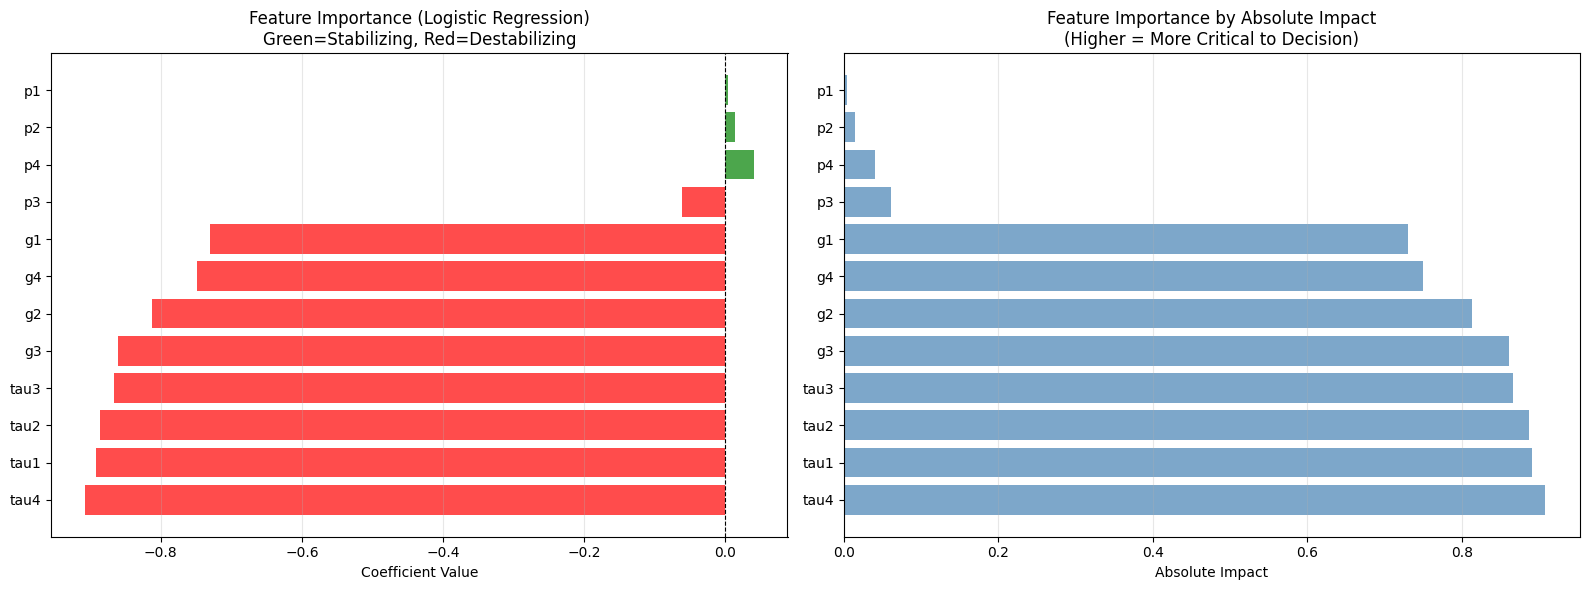


🚨 TOP 3 CRITICAL PARAMETERS FOR GRID STABILITY
1. tau4            (Impact: 0.9074)
2. tau1            (Impact: 0.8910)
3. tau2            (Impact: 0.8867)


In [15]:
import numpy as np


print("\n" + "=" * 60)
print("FEATURE IMPORTANCE & GRID VULNERABILITY ANALYSIS")
print("=" * 60)

# 1. Extract the coefficients (weights) from your trained model
coefficients = model.coef_[0]
feature_names = X.columns
intercept = model.intercept_[0]

# 2. Create a detailed table
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# 3. Sort by absolute impact
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("\nFeature Importance Ranking:")
print("(Positive = Stabilizing | Negative = Destabilizing)\n")
for idx, row in feature_importance.iterrows():
    impact_type = "STABILIZING  " if row['Coefficient'] > 0 else "DESTABILIZING"
    print(f"{row['Feature']:10} | Coef: {row['Coefficient']:8.4f} | {impact_type} | Impact: {row['Abs_Coefficient']:.4f}")

print(f"\nModel Intercept (bias): {intercept:.4f}")

# ========== ISSUE #8: Export feature importance to CSV ==========
importance_path = os.path.join(CONFIG['output_dir'], 'feature_importance_logistic.csv')
feature_importance.to_csv(importance_path, index=False)
print(f"\n✓ Feature importance saved to: {importance_path}")

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sorted bar plot
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
axes[0].barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Feature Importance (Logistic Regression)\nGreen=Stabilizing, Red=Destabilizing')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Absolute importance
axes[1].barh(feature_importance['Feature'], feature_importance['Abs_Coefficient'],
             color='steelblue', alpha=0.7)
axes[1].set_xlabel('Absolute Impact')
axes[1].set_title('Feature Importance by Absolute Impact\n(Higher = More Critical to Decision)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 5. Top 3 Grid Parameters to Monitor
print("\n" + "=" * 60)
print("🚨 TOP 3 CRITICAL PARAMETERS FOR GRID STABILITY")
print("=" * 60)
top_3 = feature_importance.head(3)
for rank, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f"{rank}. {row['Feature']:15} (Impact: {row['Abs_Coefficient']:.4f})")


DECISION TREE MODEL - COMPARISON & EVALUATION
🔑 KEY DIFFERENCE: Decision Trees work on UNSCALED data (no scaling needed)

✓ Decision Tree trained on UNSCALED data

--- CROSS-VALIDATION (5-Fold Stratified) ---
Cross-Val Accuracy: 0.8455 ± 0.0116
Cross-Val F1-Score: 0.7960 ± 0.0146

MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE

           Metric Logistic Regression Decision Tree
         Accuracy              81.85%        85.85%
Balanced Accuracy              79.29%        85.50%
         F1-Score              0.7364        0.8117
 CV Accuracy Mean              0.8154        0.8455

✓ BEST MODEL: Decision Tree (85.85% accuracy)


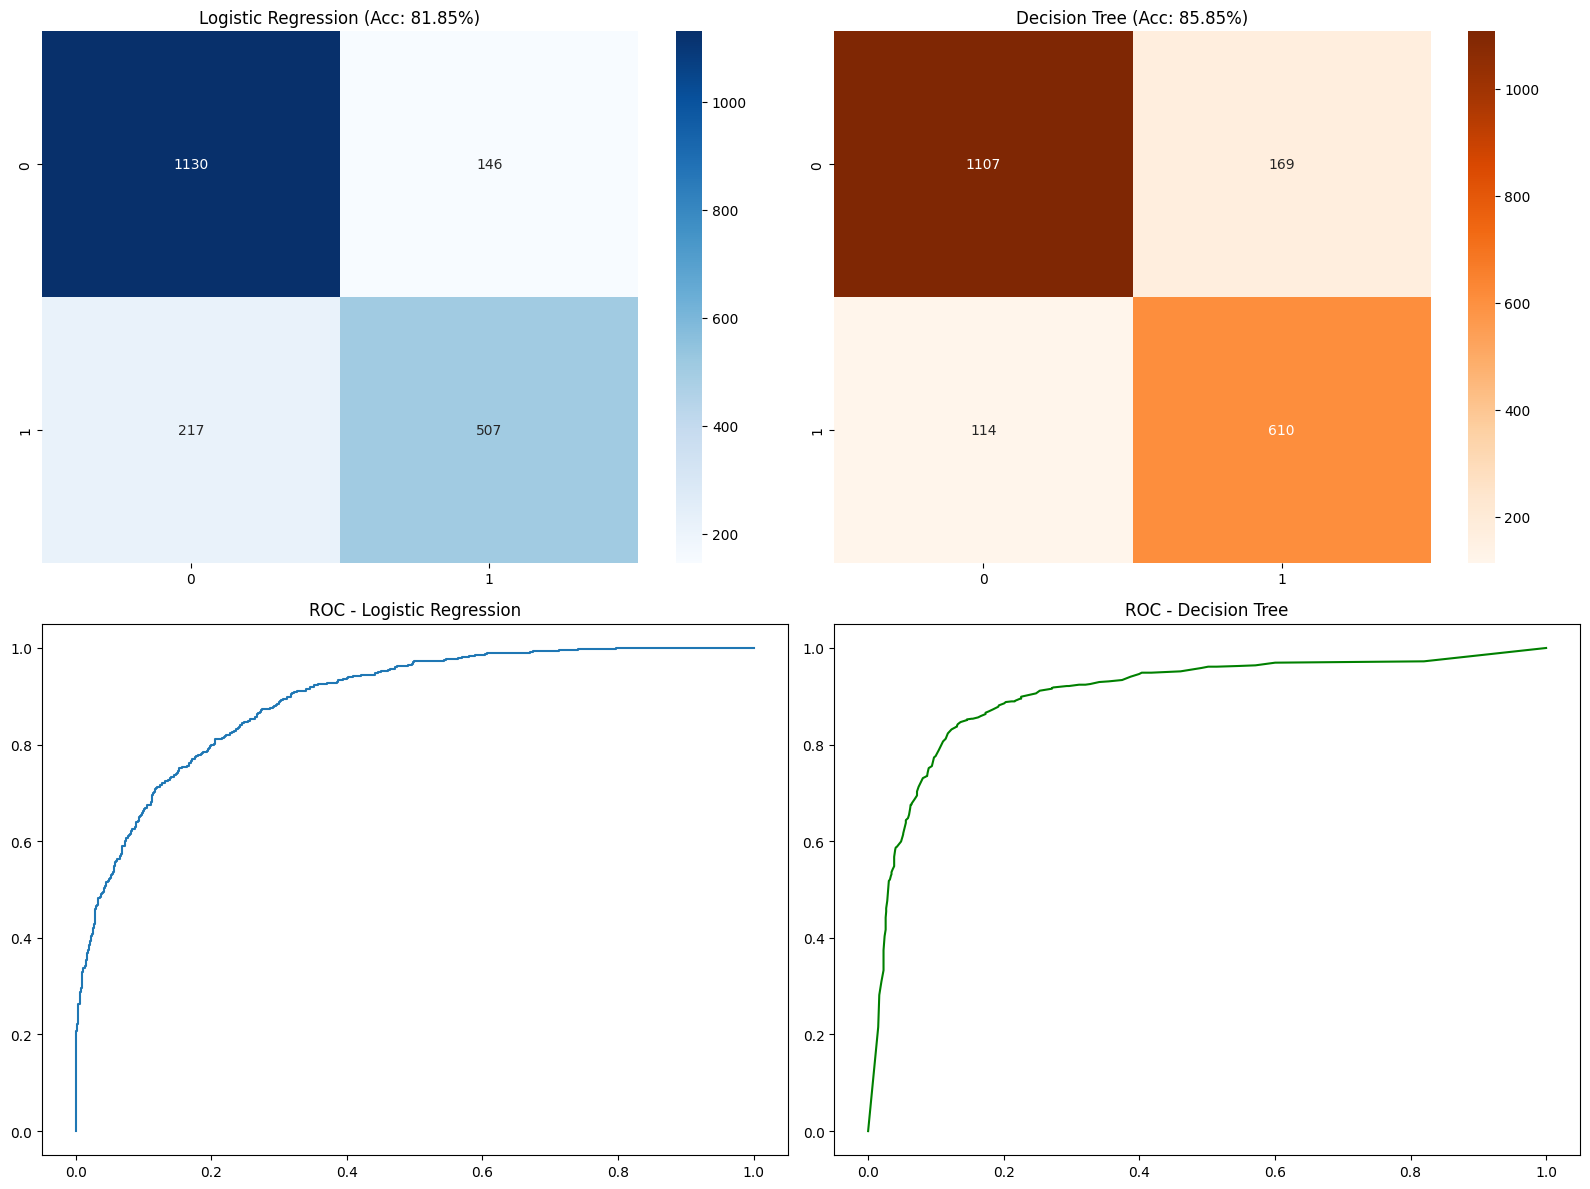


--- DECISION TREE FEATURE IMPORTANCE ---
  Feature  Importance
3    tau4    0.153021
2    tau3    0.146177
1    tau2    0.145699
0    tau1    0.128405
8      g1    0.115032


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import os

print("\n" + "=" * 60)
print("DECISION TREE MODEL - COMPARISON & EVALUATION")
print("=" * 60)
print("🔑 KEY DIFFERENCE: Decision Trees work on UNSCALED data (no scaling needed)\n")

# 1. Initialize the Decision Tree with CONFIG parameters
dt_model = DecisionTreeClassifier(
    max_depth=CONFIG['dt_max_depth'],
    random_state=CONFIG['random_state'],
    min_samples_split=CONFIG['dt_min_samples_split'],
    min_samples_leaf=CONFIG['dt_min_samples_leaf'],
    class_weight='balanced'
)

# 2. Train on UNSCALED data
dt_model.fit(X_train, y_train)
print("✓ Decision Tree trained on UNSCALED data")

# 3. CROSS-VALIDATION
print(f"\n--- CROSS-VALIDATION ({CONFIG['cv_splits']}-Fold Stratified) ---")
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv_strategy, scoring='accuracy')
dt_cv_f1 = cross_val_score(dt_model, X_train, y_train, cv=cv_strategy, scoring='f1')
print(f"Cross-Val Accuracy: {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}")
print(f"Cross-Val F1-Score: {dt_cv_f1.mean():.4f} ± {dt_cv_f1.std():.4f}")

# 4. Predictions
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# 5. Metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_balanced_acc = balanced_accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

# 6. Comparison Table
print("\n" + "=" * 60)
print("MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE")
print("=" * 60)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'F1-Score', 'CV Accuracy Mean'],
    'Logistic Regression': [
        f"{accuracy * 100:.2f}%",
        f"{balanced_acc * 100:.2f}%",
        f"{f1:.4f}",
        f"{cv_scores.mean():.4f}"
    ],
    'Decision Tree': [
        f"{dt_accuracy * 100:.2f}%",
        f"{dt_balanced_acc * 100:.2f}%",
        f"{dt_f1:.4f}",
        f"{dt_cv_scores.mean():.4f}"
    ]
})
print("\n" + comparison.to_string(index=False))

# Best model determination
if accuracy > dt_accuracy:
    best_model = "Logistic Regression"
    best_accuracy = accuracy
else:
    best_model = "Decision Tree"
    best_accuracy = dt_accuracy

print(f"\n✓ BEST MODEL: {best_model} ({best_accuracy * 100:.2f}% accuracy)")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title(f'Logistic Regression (Acc: {accuracy*100:.2f}%)')

cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1])
axes[0, 1].set_title(f'Decision Tree (Acc: {dt_accuracy*100:.2f}%)')

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
axes[1, 0].plot(fpr_lr, tpr_lr, label=f'LR (AUC = {auc(fpr_lr, tpr_lr):.3f})')
axes[1, 0].set_title('ROC - Logistic Regression')

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
axes[1, 1].plot(fpr_dt, tpr_dt, color='green', label=f'DT (AUC = {auc(fpr_dt, tpr_dt):.3f})')
axes[1, 1].set_title('ROC - Decision Tree')

plt.tight_layout()
plt.show()

# Feature Importance
dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- DECISION TREE FEATURE IMPORTANCE ---")
print(dt_feature_importance.head(5))

dt_importance_path = os.path.join(CONFIG['output_dir'], 'feature_importance_decision_tree.csv')
dt_feature_importance.to_csv(dt_importance_path, index=False)


OPERATIONAL THRESHOLD ANALYSIS - NERC EARLY WARNING SYSTEM

Threshold Analysis - Testing Different Safety Levels:

Threshold    Sensitivity  Specificity  Precision    F1-Score    
------------------------------------------------------------
0.50         0.700        0.886        0.776        0.736       
0.60         0.612        0.922        0.816        0.699       
0.70         0.507        0.956        0.868        0.640       
0.75         0.463        0.969        0.896        0.610       
0.80         0.388        0.979        0.912        0.545       
0.90         0.233        0.997        0.977        0.377       

✓ RECOMMENDED THRESHOLD: 0.50 (F1-Score: 0.7364)

NERC EARLY WARNING SYSTEM (Threshold = 75%)の時間)
Interpretation: Grid must have ≥75% confidence to be declared SAFE
Otherwise: EMERGENCY ACTION TRIGGERED

Classification Report:
                  precision    recall  f1-score   support

Emergency Action       0.76      0.97      0.85      1276
       Grid Safe       

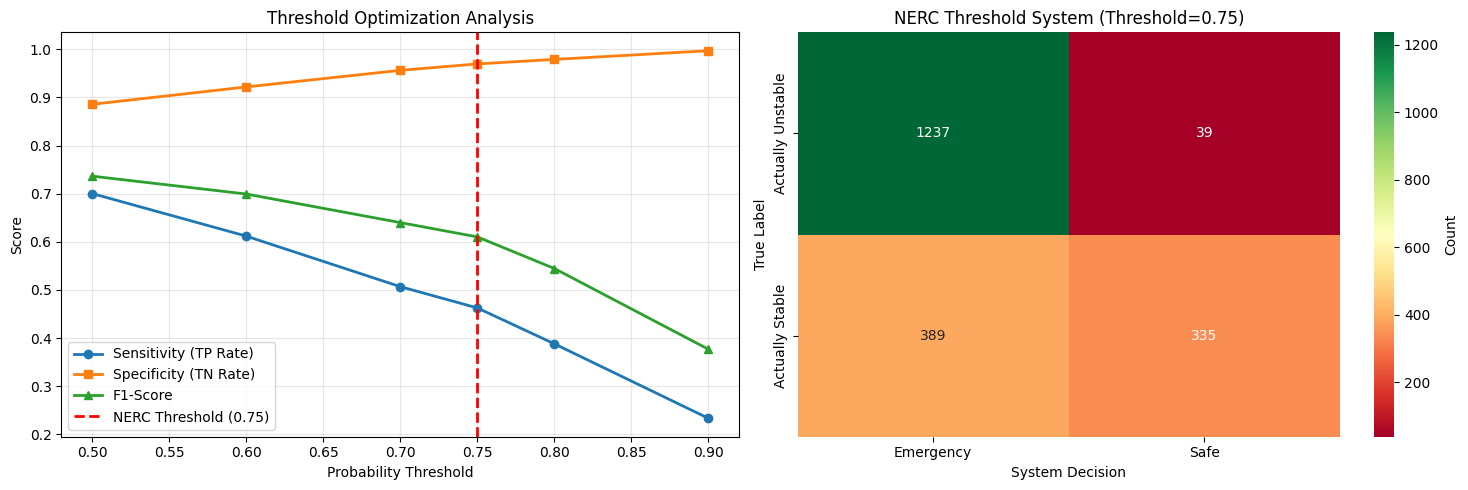


PREDICTION METADATA & CONFIDENCE ANALYSIS

Sample Predictions with Confidence Metrics:
   Actual_Stability  Predicted_Stability  Prediction_Confidence  Probability_Stable  Correct_Prediction
0                 0                    0               0.926760            0.073240                   1
1                 0                    0               0.976694            0.023306                   1
2                 0                    0               0.968499            0.031501                   1
3                 1                    1               0.730231            0.730231                   1
4                 0                    0               0.501402            0.498598                   1
5                 1                    1               0.843976            0.843976                   1
6                 1                    1               0.511465            0.511465                   1
7                 0                    0               0.992617            0.007

In [18]:
import numpy as np
import joblib # Import joblib for saving and loading models

print("\n" + "=" * 60)
print("OPERATIONAL THRESHOLD ANALYSIS - NERC EARLY WARNING SYSTEM")
print("=" * 60)

# 1. Get the raw probabilities of being STABLE (Class 1)
probabilities = model.predict_proba(X_test_scaled)[:, 1]

# 2. Test multiple thresholds to find optimal trade-off
thresholds_to_test = [0.50, 0.60, 0.70, 0.75, 0.80, 0.90]

print("\nThreshold Analysis - Testing Different Safety Levels:\n")
print(f"{'Threshold':<12} {'Sensitivity':<12} {'Specificity':<12} {'Precision':<12} {'F1-Score':<12}")
print("-" * 60)

threshold_results = []

for threshold in thresholds_to_test:
    custom_pred = (probabilities >= threshold).astype(int)

    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, custom_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_th = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    threshold_results.append({
        'Threshold': threshold,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1': f1_th,
        'Custom_Pred': custom_pred
    })

    print(f"{threshold:<12.2f} {sensitivity:<12.3f} {specificity:<12.3f} {precision:<12.3f} {f1_th:<12.3f}")

# 3. Recommend optimal threshold
optimal_idx = np.argmax([r['F1'] for r in threshold_results])
optimal_threshold = threshold_results[optimal_idx]['Threshold']
print(f"\n✓ RECOMMENDED THRESHOLD: {optimal_threshold:.2f} (F1-Score: {threshold_results[optimal_idx]['F1']:.4f})")

# ========== ISSUE #4: Use configurable NERC threshold from CONFIG ==========
nerc_threshold = CONFIG['nerc_threshold']
custom_predictions = (probabilities >= nerc_threshold).astype(int)

print(f"\n" + "=" * 60)
print(f"NERC EARLY WARNING SYSTEM (Threshold = {nerc_threshold*100:.0f}%)の時間)")
print("=" * 60)
print("Interpretation: Grid must have ≥75% confidence to be declared SAFE")
print("Otherwise: EMERGENCY ACTION TRIGGERED\n")

nerc_cm = confusion_matrix(y_test, custom_predictions)
tn, fp, fn, tp = nerc_cm.ravel()

print("Classification Report:")
print(classification_report(y_test, custom_predictions,
                           target_names=['Emergency Action', 'Grid Safe']))

print(f"\nOperational Breakdown:")
print(f"  True Negatives (Correct Emergency):  {tn:5d}  (avoiding false alarms)")
print(f"  False Positives (False Alarms):      {fp:5d}  (unnecessary activations)")
print(f"  False Negatives (MISSED RISKS):      {fn:5d}  ⚠️  CRITICAL")
print(f"  True Positives (Correct Safe):       {tp:5d}")

# 5. Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metrics vs Threshold
thresholds_plot = [r['Threshold'] for r in threshold_results]
sensitivity_plot = [r['Sensitivity'] for r in threshold_results]
specificity_plot = [r['Specificity'] for r in threshold_results]
f1_plot = [r['F1'] for r in threshold_results]

axes[0].plot(thresholds_plot, sensitivity_plot, marker='o', label='Sensitivity (TP Rate)', linewidth=2)
axes[0].plot(thresholds_plot, specificity_plot, marker='s', label='Specificity (TN Rate)', linewidth=2)
axes[0].plot(thresholds_plot, f1_plot, marker='^', label='F1-Score', linewidth=2)
axes[0].axvline(x=nerc_threshold, color='red', linestyle='--', linewidth=2, label=f'NERC Threshold ({nerc_threshold})')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Optimization Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: NERC Confusion Matrix
sns.heatmap(nerc_cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Emergency', 'Safe'],
            yticklabels=['Actually Unstable', 'Actually Stable'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'NERC Threshold System (Threshold={nerc_threshold})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('System Decision')

plt.tight_layout()
plt.show()

# ========== ISSUE #10: Add prediction metadata with confidence intervals ==========
print("\n" + "=" * 60)
print("PREDICTION METADATA & CONFIDENCE ANALYSIS")
print("=" * 60)

# Create prediction dataframe with confidence info
predictions_metadata = pd.DataFrame({
    'Actual_Stability': y_test.values,
    'Predicted_Stability': y_pred,
    'Prediction_Confidence': np.maximum(y_prob, 1 - y_prob),  # Confidence of the prediction
    'Probability_Stable': y_prob,
    'Correct_Prediction': (y_test.values == y_pred).astype(int)
})

print("\nSample Predictions with Confidence Metrics:")
print(predictions_metadata.head(10).to_string())

# Analyze confidence distribution
low_conf = (predictions_metadata['Prediction_Confidence'] < 0.6).sum()
med_conf = ((predictions_metadata['Prediction_Confidence'] >= 0.6) &
            (predictions_metadata['Prediction_Confidence'] < 0.8)).sum()
high_conf = (predictions_metadata['Prediction_Confidence'] >= 0.8).sum()

print(f"\nConfidence Distribution:")
print(f"  Low Confidence (<60%):  {low_conf:5d} predictions")
print(f"  Medium Confidence:      {med_conf:5d} predictions")
print(f"  High Confidence (≥80%): {high_conf:5d} predictions")

# Save metadata
metadata_path = os.path.join(CONFIG['output_dir'], 'prediction_metadata.csv')
predictions_metadata.to_csv(metadata_path, index=False)
print(f"\n✓ Prediction metadata saved to: {metadata_path}")

# ========== ISSUE #2 & #5: Use CONFIG for model paths and validate before saving ==========
print("\n" + "=" * 60)
print("MODEL PERSISTENCE - SAVING FOR PRODUCTION")
print("=" * 60)

model_path = os.path.join(CONFIG['model_dir'], 'voltage_stability_model.pkl')
scaler_path = os.path.join(CONFIG['model_dir'], 'voltage_scaler.pkl')
config_path = os.path.join(CONFIG['model_dir'], 'config.pkl')

# ========== ISSUE #5: Validate models before saving ==========
print("\nValidating models before persistence...")
try:
    # Test predictions
    test_pred = model.predict(X_test_scaled)
    test_prob = model.predict_proba(X_test_scaled)

    # Validate scaler
    test_scaled = scaler.transform(X_test)

    if test_pred.shape[0] > 0 and test_scaled.shape[0] > 0:
        print("✓ Model validation passed")
    else:
        raise ValueError("Model validation failed: empty predictions")
except Exception as e:
    print(f"✗ Model validation failed: {e}")
    raise

# Save models
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(CONFIG, config_path)

print(f"✓ Model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")
print(f"✓ Config saved to: {config_path}")

# Save all metrics summary
metrics_summary = {
    'Model': 'Logistic Regression',
    'Test_Accuracy': accuracy,
    'Test_F1_Score': f1,
    'Test_Balanced_Accuracy': balanced_acc,
    'CV_Accuracy_Mean': cv_scores.mean(),
    'CV_Accuracy_Std': cv_scores.std(),
    'ROC_AUC': roc_auc,
    'Training_Samples': X_train.shape[0],
    'Test_Samples': X_test.shape[0]
}

metrics_path = os.path.join(CONFIG['output_dir'], 'model_metrics.pkl')
joblib.dump(metrics_summary, metrics_path)
print(f"✓ Metrics saved to: {metrics_path}")

print("\nTo use the saved model in production:")
print(f"  loaded_model = joblib.load('{model_path}')")
print(f"  loaded_scaler = joblib.load('{scaler_path}')")
print(f"  loaded_config = joblib.load('{config_path}')")
print(f"  X_new_scaled = loaded_scaler.transform(X_new)")
print(f"  predictions = loaded_model.predict(X_new_scaled)")
print(f"  probabilities = loaded_model.predict_proba(X_new_scaled)")

print("\n" + "=" * 60)
print("✓ ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nOutputs saved to: {CONFIG['output_dir']}/")
print(f"Models saved to: {CONFIG['model_dir']}/")